In [2]:
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.table import Table
from astropy.io import fits
from astropy.visualization import simple_norm
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import re
from astropy.coordinates import SkyCoord
import sys
sys.path.append('/home/t.yoo/Paths')
import Paths.Paths as paths
import matplotlib as mpl
import matplotlib.patches as patches
Path = paths.filepaths()

import warnings
from astropy.wcs import FITSFixedWarning
from astroquery.svo_fps import SvoFps

warnings.filterwarnings("ignore", category=FITSFixedWarning)

plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    "w51e_1.3mm": Path.w51e_b6_tt0,
    "w51e_3mm": Path.w51e_b3_tt0,
    "w51n_1.3mm": Path.w51n_b6_tt0,
    "w51n_3mm": Path.w51n_b3_tt0,
    "vla_22GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-K-B.S1-ICLN.DAVID-MEH.fits",
    "vla_14GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51Ku_C_Aarray_continuum_2048_high_uniform.clean.image.fits",
    "vla_8GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-X-ABCD-S1.VTESS.VTC.DAVID-MEH.fits",
    "vla_5GHz": "/orange/adamginsburg/w51/TaehwaYoo/vla/2016paper/W51-CBAND-feathered.fits"
}
catalogs_filters = {"f140m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f162m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f182m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f187n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f210m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f335m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f360m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f405n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f410m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f480m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f140m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f162m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                  "f182m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f187n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f210m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f335m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f360m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f405n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f410m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f480m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                   "f560w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f770w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f1000w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f1280w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "f2100w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                   "vla": '/home/t.yoo/w51/w51_nircam/analysis/vla.fits',
                  }
                  
catalogs_filters_filtered = {"f140m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f162m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f182m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f187n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f210m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f335m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f360m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f405n_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f410m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f480m_nrca": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f140m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f162m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                  "f182m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f187n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f210m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f335m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f360m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f405n_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f410m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f480m_nrcb": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits',
                   "f560w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f770w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f1000w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f1280w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "f2100w": '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_b_fixed.fits',
                   "vla": '/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated.fits',
                  }
reprojected_dir = '/orange/adamginsburg/jwst/w51/reproject_to_alma/'

def get_mag(flux, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    #flux= (flux * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
   # eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
 #   abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
#    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) 
 #   vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag


catalog = Table.read('/orange/adamginsburg/jwst/w51/catalogs/final_nircam_miri_indivexp_merged_dao_refined_after_sat.fits')
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')

def plot_SED(image_filenames, row_jwst, row_alma, row_vla, label, cutout_size=2*u.arcsec, alma_region='w51e', show=False):
  


    fig = plt.figure(figsize=(22, 10))
    gs = GridSpec(5,11, figure=fig, wspace=0, hspace=0)
    ax_f140m = fig.add_subplot(gs[0,0])
    ax_f162m = fig.add_subplot(gs[0,1])
    ax_f182m = fig.add_subplot(gs[0,2])
    ax_f187n = fig.add_subplot(gs[0,3])
    ax_f210m = fig.add_subplot(gs[0,4])
    ax_f335m = fig.add_subplot(gs[0,5])
    ax_f360m = fig.add_subplot(gs[0,6])
    ax_f405n = fig.add_subplot(gs[0,7])
    ax_f410m = fig.add_subplot(gs[0,8])
    ax_f480m = fig.add_subplot(gs[0,9])
    ax_f560w = fig.add_subplot(gs[0,10])
    ax_f770w = fig.add_subplot(gs[1,0])
    ax_f1000w = fig.add_subplot(gs[1,1])
    ax_f1280w = fig.add_subplot(gs[1,2])
    ax_f2100w = fig.add_subplot(gs[1,3])
    ax_b6 = fig.add_subplot(gs[1,4])
    ax_b3 = fig.add_subplot(gs[1,5])
    ax_vla_22GHz = fig.add_subplot(gs[1,6])
    ax_vla_14GHz = fig.add_subplot(gs[1,7])
    ax_vla_8GHz = fig.add_subplot(gs[1,8])
    ax_vla_5GHz = fig.add_subplot(gs[1,9])
    ax_images = [ax_f140m, ax_f162m, ax_f182m, ax_f187n, ax_f210m, ax_f335m, ax_f360m, ax_f405n,
                 ax_f410m, ax_f480m, ax_f560w, ax_f770w, ax_f1000w, ax_f1280w, ax_f2100w, ax_b6, ax_b3, ax_vla_22GHz, ax_vla_14GHz, ax_vla_8GHz, ax_vla_5GHz]
    ax_main = fig.add_subplot(gs[2:5, :])
    filter_names = ["f140m", "f162m", "f182m", "f187n", "f210m", "f335m", "f360m", "f405n",
                    "f410m", "f480m", "f560w", "f770w", "f1000w", "f1280w", "f2100w", "1.3mm", "3mm",  "vla_22GHz", "vla_14GHz", "vla_8GHz", "vla_5GHz", ]
    skycoords = SkyCoord(ra=catalog['skycoord_ref'].ra[idx], dec=catalog['skycoord_ref'].dec[idx])
    print('skycoords in h:m:s:', skycoords.to_string('hmsdms'))
    print(len(filter_names), len(ax_images))
    for i, ax in enumerate(ax_images):  
       

        img_b3 = image_filenames[f'{alma_region}_3mm']
        header_b3 = fits.open(img_b3)[0].header
        pixel_scale_b3 = WCS(header_b3, naxis=2).proj_plane_pixel_scales()[0]
        img_b6 = image_filenames[f'{alma_region}_1.3mm']
        header_b6 = fits.open(img_b6)[0].header
        pixel_scale_b6 = WCS(header_b6, naxis=2).proj_plane_pixel_scales()[0]

        if filter_names[i] in ["1.3mm", "3mm"]: 
            if filter_names[i] == "1.3mm":
                band = 'b6'
            elif filter_names[i] == "3mm":
                band = 'b3'
            img_filename = image_filenames[f"{alma_region}_{filter_names[i]}"]
            print('alma image filename:', img_filename)
            img = fits.open(img_filename)[0].data[0][0]
            header = fits.open(img_filename)[0].header
            wcs = WCS(header, naxis=2)
        elif filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
            #filt}_reprojected_to_alma_w51n_b6.fits
            img_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            print('JWST image filename:', img_filename)
            img = fits.open(img_filename)[0].data
            header = fits.open(img_filename)[0].header
            wcs = WCS(header, naxis=2)
        else:
            
            image_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            img = fits.open(image_filename)[0].data
            if not len(img.shape) == 2:
                img = img[0][0]
            header = fits.open(image_filename)[0].header
            wcs = WCS(header, naxis=2)
          

        try:
        
            cutout = Cutout2D(img, skycoords, (cutout_size, cutout_size), wcs=wcs)
            norm = simple_norm(cutout.data, 'sqrt', percent=99.5)
            ax.imshow(cutout.data, norm=norm, origin='lower', cmap='inferno')
            if filter_names[i] == "1.3mm":
                pixel_scale = pixel_scale_b6
            else:
                pixel_scale = pixel_scale_b3
            print('pixel_scale:', pixel_scale)
                
            circle = patches.Circle((cutout.data.shape[1]/2, cutout.data.shape[0]/2), radius=(0.1*u.arcsec/pixel_scale).to(u.deg/u.deg).value, edgecolor='cyan', facecolor='none', lw=2)
            ax.add_patch(circle)
            print(filter_names[i])
            ax.text(0.1, 0.9, filter_names[i].upper(), transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
            ax.axis('off')
            ax.set_xlim(0, cutout.data.shape[1])
            ax.set_ylim(0, cutout.data.shape[0])
        except Exception as e:
            print(img.shape)
            pixcoord = skycoords.to_pixel(wcs)
            print('pixcoord:', pixcoord)
            print(f"Could not create cutout for filter {filter_names[i]}: {e}")
            # imshow empty 2d array
            ax.imshow(np.zeros((100, 100)), origin='lower', cmap='inferno')
            ax.text(0.1, 0.9, filter_names[i].upper(), transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
            ax.axis('off')
            ax.set_xlim(0, cutout.data.shape[1])
            ax.set_ylim(0, cutout.data.shape[0])
                 
        
            
        if not filter_names[i] in ['1.3mm', '3mm']:
            if filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
                cat_nrca = catalogs_filters_filtered[f'{filter_names[i]}_nrca']
                skycoord_nrca = Table.read(cat_nrca)['skycoord']
                print('catalog filename cat_nrca:', cat_nrca)
                pixcoord_nrca = skycoord_nrca.to_pixel(cutout.wcs)
                cat_nrcb = catalogs_filters_filtered[f'{filter_names[i]}_nrcb']
                print('catalog filename cat_nrcb:', cat_nrcb)

                skycoord_nrcb = Table.read(cat_nrcb)['skycoord']
                pixcoord_nrcb = skycoord_nrcb.to_pixel(cutout.wcs)
                ax.scatter(pixcoord_nrca[0], pixcoord_nrca[1], facecolor='none', color='blue', s=10)
                ax.scatter(pixcoord_nrcb[0], pixcoord_nrcb[1], facecolor='none', color='red', s=10)
                
            
            elif filter_names[i] in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
                cat_miri = catalogs_filters_filtered[f'{filter_names[i]}']
                print('catalog filename cat_miri:', cat_miri)
                skycoord_miri = Table.read(cat_miri)['skycoord']
                pixcoord_miri = skycoord_miri.to_pixel(cutout.wcs)
                ax.scatter(pixcoord_miri[0], pixcoord_miri[1], facecolor='none', color='green', s=10)

            else:
                
                cat_vla = Table.read(catalogs_filters_filtered['vla'])
                print('catalog filename cat_vla:', catalogs_filters_filtered['vla'])
                ra = cat_vla['GRAdeg']
                dec = cat_vla['GDEdeg']
                freq = cat_vla['Freq']
                freq_selected = filter_names[i].split('_')[1]
                if freq_selected.endswith('GHz'):
                    freq_selected = freq_selected[:-3]  # Remove 'GHz' from the end
                freq_idx = np.where(np.isclose(freq, float(freq_selected), rtol=0.1))[0]
                if len(freq_idx) > 0:
                    ra = ra[freq_idx]
                    dec = dec[freq_idx]
                    skycoord_vla = SkyCoord(ra=ra, dec=dec)
                    pixcoord_vla = skycoord_vla.to_pixel(cutout.wcs)
                    ax.scatter(pixcoord_vla[0], pixcoord_vla[1], facecolor='none', color='magenta', s=10)

        # limit xlim ylim as same as cutout size
       
    # plot SED
    colors = mpl.cm.viridis(np.linspace(0, 1, len(filter_names)))
    fluxarr = []
    mag_f140m = None
    mag_f210m = None
    mag_f360m = None
    mag_f480m = None
    for i, filter_name in enumerate(filter_names):
        flux_jy = np.nan * u.Jy
        is_upperlimit=False
        # Get the effective wavelength for each filter
      

        if filter_name == '1.3mm':
            wav = 1300
            flux_jy = row_alma['flux_b6'] * u.Jy if not hasattr(row_alma['flux_b6'], 'unit') else row_alma['flux_b6']
        elif filter_name == '3mm':
            wav = 3000
            flux_jy = row_alma['flux_b3'] * u.Jy if not hasattr(row_alma['flux_b3'], 'unit') else row_alma['flux_b3']
        elif filter_name in ["vla_5GHz", "vla_8GHz", "vla_14GHz", "vla_22GHz"]:
            if row_vla is not None:
                freq_selected = filter_name.split('_')[1]
                if freq_selected.endswith('GHz'):
                    freq_selected = freq_selected[:-3]  # Remove 'GHz' from the end        
                print('freq_selected:', freq_selected)
                freq = row_vla['Freq']
                freq_idx = np.where(np.isclose(freq, float(freq_selected), rtol=0.1))[0]
                if len(freq_idx) > 0:
                    #flux_jy = row_vla['FluxPk'][freq_idx] * u.Jy if not hasattr(row_vla['FluxPk'], 'unit') else row_vla['FluxPk'][freq_idx]
                    # get flux_jy with the most recent obs_date
                    obs_date = row_vla['Obs_date'][freq_idx]
                    if isinstance(obs_date, np.ma.MaskedArray):
                        obs_date = obs_date.data
                    if len(obs_date) > 1:
                        latest_idx = np.argmax(obs_date)
                        flux_jy = row_vla['FluxPk'][freq_idx][latest_idx] * u.Jy if not hasattr(row_vla['FluxPk'][freq_idx][latest_idx], 'unit') else row_vla['FluxPk'][freq_idx][latest_idx]
                        wav = (3e8 / (freq[freq_idx][latest_idx] * 1e9)) * 1e6 # convert frequency in GHz to wavelength in micron
                        print('wav in vla', wav)
                    else:
                        flux_jy = row_vla['FluxPk'][freq_idx] * u.Jy if not hasattr(row_vla['FluxPk'][freq_idx], 'unit') else row_vla['FluxPk'][freq_idx]
                        wav = (3e8 / (freq[freq_idx] * 1e9)) * 1e6 # convert frequency in GHz to wavelength in micron
                        print('wav in vla', wav)
                else:
                    print(f"No matching frequency found in VLA catalog for {filter_name}")
                    flux_jy = np.nan * u.Jy
            else:
                flux_jy = np.nan * u.Jy

        else:
            print(filter_name)
            wcs_filter = WCS(fits.getheader(image_filenames[filter_name], ext=('SCI', 1)), naxis=2)
            wav = int(filter_name[1:-1])/100
            flux_jy = (row_jwst['flux_fit_' + filter_name] * u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy) # convert surface brightness to flux density in Jy
        

        print('flux_jy:', flux_jy)

        if np.isnan(flux_jy) or flux_jy <= 0 or np.ma.is_masked(flux_jy):
            if filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
                print(f"Flux for filter {filter_name} is NaN or non-positive, checking catalogs for upper limits...")
                cat_nrca = catalogs_filters_filtered[f'{filter_names[i]}_nrca']
                skycoord_nrca = Table.read(cat_nrca)['skycoord']
                cat_nrcb = catalogs_filters_filtered[f'{filter_names[i]}_nrcb']
                skycoord_nrcb = Table.read(cat_nrcb)['skycoord']
                # get the sources that are within 0.1 arcsec from the target source in the catalog, and use their fluxes as upper limits
                idx_nrca = skycoord_nrca.separation(skycoords) < 0.1*u.arcsec
                idx_nrcb = skycoord_nrcb.separation(skycoords) < 0.1*u.arcsec
                if np.any(idx_nrca):
                    flux_nrca = Table.read(cat_nrca)['flux_fit'][idx_nrca]
                    flux_nrca = flux_nrca[~np.isnan(flux_nrca)]
                    if len(flux_nrca) > 0:
                        print('flux_nrca:', flux_nrca)
                        flux_jy = np.max(flux_nrca* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
                if np.any(idx_nrcb):
                    flux_nrcb = Table.read(cat_nrcb)['flux_fit'][idx_nrcb]
                    flux_nrcb = flux_nrcb[~np.isnan(flux_nrcb)]
                    if len(flux_nrcb) > 0:
                        print('flux_nrcb:', flux_nrcb)
                        flux_jy = np.max(flux_nrcb* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            elif filter_names[i] in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
                cat_miri = catalogs_filters[f'{filter_names[i]}']
                skycoord_miri = Table.read(cat_miri)['skycoord']
                idx_miri = skycoord_miri.separation(skycoords) < 0.1*u.arcsec
                if np.any(idx_miri):
                    flux_miri = Table.read(cat_miri)['flux_fit'][idx_miri]
                    flux_miri = flux_miri[~np.isnan(flux_miri)]
                    if len(flux_miri) > 0:
                        flux_jy = np.max(flux_miri* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            """
            if np.isnan(flux_jy) or flux_jy <= 0  or np.ma.is_masked(flux_jy): # if the flux is still NaN or non-positive, get the pixel value within the area of FWHM at the center of the cutout as upper limit
                # get the pixel value within the area of FWHM at the center of the cutout
                aperture_reg = CirclePixelregion(center=(cutout.data.shape[1]/2, cutout.data.shape[0]/2), radius=(fwhm_pix/2))
                mask_cutout = aperture_reg.to_mask(method='center')
                cutout_masked = mask_cutout.multiply(cutout.data)
                flux = (np.sum(cutout_masked)*4* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
                is_upperlimit = True
            """        
            
                
        if np.isfinite(flux_jy) and filter_names[i] in ['f182m']:
            #flux_f182m = (flux* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            hdr_f182m = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
            wcs_f182m = WCS(hdr_f182m, naxis=2)
            mag_f182m = get_mag(flux_jy, wcs_f182m, filtername='f182m')
        elif np.isfinite(flux_jy) and filter_names[i] in ['f210m']:
            #flux_f210m = (flux_jy* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            hdr_f210m = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
            wcs_f210m = WCS(hdr_f210m, naxis=2)
            mag_f210m = get_mag(flux_jy, wcs_f210m, filtername='f210m')
        elif np.isfinite(flux_jy) and filter_names[i] in ['f360m']:
            #flux_f360m = (flux_jy* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            hdr_f360m = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
            wcs_f360m = WCS(hdr_f360m, naxis=2)
            mag_f360m = get_mag(flux_jy, wcs_f360m, filtername='f360m')
        elif np.isfinite(flux_jy) and filter_names[i] in ['f480m']:
            #flux_f480 = (flux_jy* u.MJy / u.sr * wcs_filter.proj_plane_pixel_area()).to(u.Jy)
            hdr_f480m = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
            wcs_f480m = WCS(hdr_f480m, naxis=2)
            mag_f480m = get_mag(flux_jy, wcs_f480m, filtername='f480m')
        print(f"Filter: {filter_name}, Wavelength: {wav} micron, Flux: {flux_jy}")
        flux_value = flux_jy.to_value(u.Jy) if hasattr(flux_jy, 'to_value') else float(flux_jy)
        if is_upperlimit:
            ax_main.errorbar(wav , flux_value, yerr=flux_value*0.5, uplims=True, color=colors[i], marker='o', markersize=20, label=filter_name.upper())
        
        ax_main.plot(wav , flux_value, color = colors[i], marker='o', markersize=20, 
            label=filter_name.upper())
        
        ax_main.vlines(wav, ymin=1e-10, ymax=1e10, colors=colors[i], linestyles='dashed', alpha=0.5)
        fluxarr.append(flux_value)
    print('fluxarr',fluxarr)
    fluxarr = np.array(fluxarr, dtype=float)
    ax_main.set_xscale('log')
    ax_main.set_yscale('log')
    ax_main.set_xlabel('Wavelength (micron)')
    ax_main.set_ylabel('Flux (Jy)')
    ax_main.text(0.7, 0.9, f'SED for Source {label}', transform=ax_main.transAxes, fontsize=26)
    if np.isfinite(mag_f182m) and np.isfinite(mag_f210m) and np.isfinite(mag_f360m) and np.isfinite(mag_f480m):
        ax_main.text(0.7,0.8, f'f182m-210m: {(mag_f182m-mag_f210m).value:.2f}, f360m-480m: {(mag_f360m-mag_f480m).value:.2f} mag', transform=ax_main.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7))
    #ax_main.legend(fontsize=12, ncol=4, bbox_to_anchor=(0.55, 0, 0.2,0.4))
    ax_main.set_ylim(1e-8, 1e4)
    ax_main.set_xlim(1, 7e4)

    
    plt.tight_layout()
    plt.savefig(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/seds/{alma_region}_source_{label}_SED.png')
    if show:
        plt.show()
    plt.close()

    if np.isfinite(mag_f182m) and np.isfinite(mag_f210m) and np.isfinite(mag_f360m) and np.isfinite(mag_f480m):
        return mag_f182m, mag_f210m, mag_f360m, mag_f480m, label
    else:
        return None, None, None, None, label


def get_number_after_hash(name):
    match = re.search(r'#(\d+)', name)
    if match:
        return int(match.group(1))
    else:
        return None 
        
def extract_sort_key(name):
    # Extract prefix before #
    prefix_match = re.match(r'(.*)#(\d+)', name)
    if prefix_match:
        prefix = prefix_match.group(1)
        number = int(prefix_match.group(2))
        return (prefix, number)
    else:
        return (name, -1)  # fallback if no match
"""
sheet_id = '1FRTQynXdrCuc-uwGIOKizEnDhFVoe9d7IuZ0CFuWIJ8'
sheet_name = 'Sheet1'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=0"
tb = Table.read(url, format='ascii.csv')
region_name = tb['region_name']
alma_band = tb['alma_band']
jwst_filt = tb['jwst_filter']
alma_overlap_list = [str(name) for name in region_name if str(name).startswith('alma_overlap')]
alma_overlap_list_sorted = sorted(alma_overlap_list, key=extract_sort_key)

sort_keys = [extract_sort_key(name) for name in alma_overlap_list]
sorting_index = sorted(range(len(alma_overlap_list)), key=lambda i: sort_keys[i])
alma_band_overlap = [str(alma_band[region_name == name][0]) for name in alma_overlap_list]
jwst_filt_overlap = [str(jwst_filt[region_name == name][0]) for name in alma_overlap_list]
print(sorting_index)
alma_band_sorted = [alma_band_overlap[i] for i in sorting_index]
jwst_filt_sorted = [jwst_filt_overlap[i] for i in sorting_index]


print(alma_overlap_list_sorted)
print(alma_band_sorted)
print(jwst_filt_sorted)

print(len(alma_overlap_list_sorted))
print(len(alma_band_sorted))
print(len(jwst_filt_sorted))
"""



'\nsheet_id = \'1FRTQynXdrCuc-uwGIOKizEnDhFVoe9d7IuZ0CFuWIJ8\'\nsheet_name = \'Sheet1\'\nurl = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid=0"\ntb = Table.read(url, format=\'ascii.csv\')\nregion_name = tb[\'region_name\']\nalma_band = tb[\'alma_band\']\njwst_filt = tb[\'jwst_filter\']\nalma_overlap_list = [str(name) for name in region_name if str(name).startswith(\'alma_overlap\')]\nalma_overlap_list_sorted = sorted(alma_overlap_list, key=extract_sort_key)\n\nsort_keys = [extract_sort_key(name) for name in alma_overlap_list]\nsorting_index = sorted(range(len(alma_overlap_list)), key=lambda i: sort_keys[i])\nalma_band_overlap = [str(alma_band[region_name == name][0]) for name in alma_overlap_list]\njwst_filt_overlap = [str(jwst_filt[region_name == name][0]) for name in alma_overlap_list]\nprint(sorting_index)\nalma_band_sorted = [alma_band_overlap[i] for i in sorting_index]\njwst_filt_sorted = [jwst_filt_overlap[i] for i in sorting_index]\n\n\nprint(alma_ove

In [3]:


"""
def plot_SED(image_filenames, row_jwst, row_alma, row_vla, label, cutout_size=2*u.arcsec, alma_region='w51e', show=False):
    fig = plt.figure(figsize=(22, 10))
    gs = GridSpec(5,11, figure=fig, wspace=0, hspace=0)
    ax_f140m = fig.add_subplot(gs[0,0])
    ax_f162m = fig.add_subplot(gs[0,1])
    ax_f182m = fig.add_subplot(gs[0,2])
    ax_f187n = fig.add_subplot(gs[0,3])
    ax_f210m = fig.add_subplot(gs[0,4])
    ax_f335m = fig.add_subplot(gs[0,5])
    ax_f360m = fig.add_subplot(gs[0,6])
    ax_f405n = fig.add_subplot(gs[0,7])
    ax_f410m = fig.add_subplot(gs[0,8])
    ax_f480m = fig.add_subplot(gs[0,9])
    ax_f560w = fig.add_subplot(gs[0,10])
    ax_f770w = fig.add_subplot(gs[1,0])
    ax_f1000w = fig.add_subplot(gs[1,1])
    ax_f1280w = fig.add_subplot(gs[1,2])
    ax_f2100w = fig.add_subplot(gs[1,3])
    ax_b6 = fig.add_subplot(gs[1,4])
    ax_b3 = fig.add_subplot(gs[1,5])
    ax_vla_5GHz = fig.add_subplot(gs[1,6])
    ax_vla_8GHz = fig.add_subplot(gs[1,7])
    ax_vla_14GHz = fig.add_subplot(gs[1,8])
    ax_vla_22GHz = fig.add_subplot(gs[1,9])
    ax_images = [ax_f140m, ax_f162m, ax_f182m, ax_f187n, ax_f210m, ax_f335m, ax_f360m, ax_f405n,
                 ax_f410m, ax_f480m, ax_f560w, ax_f770w, ax_f1000w, ax_f1280w, ax_f2100w, ax_b6, ax_b3, ax_vla_5GHz, ax_vla_8GHz, ax_vla_14GHz, ax_vla_22GHz]
    ax_main = fig.add_subplot(gs[2:5, :])
    filter_names = ["f140m", "f162m", "f182m", "f187n", "f210m", "f335m", "f360m", "f405n",
                    "f410m", "f480m", "f560w", "f770w", "f1000w", "f1280w", "f2100w", "1.3mm", "3mm", "vla_5GHz", "vla_8GHz", "vla_14GHz", "vla_22GHz"]
    
    # Extract skycoords from row_jwst - handle both skycoord_ref and separate ra/dec columns
    if 'skycoord_ref' in row_jwst.colnames:
        skycoords = SkyCoord(ra=row_jwst['skycoord_ref'].ra, dec=row_jwst['skycoord_ref'].dec)
    else:
        skycoords = SkyCoord(ra=row_jwst['skycoord_ra']*u.deg, dec=row_jwst['skycoord_dec']*u.deg)
    print('skycoords in h:m:s:', skycoords.to_string('hmsdms'))
    print(len(filter_names), len(ax_images))
    
    # Simplified implementation: skip image cutouts for now due to file issues
    # plot SED directly
    colors = mpl.cm.viridis(np.linspace(0, 1, len(filter_names)))
    fluxarr = []
    mags_f182m = None
    mags_f210m = None
    mags_f360m = None
    mags_f480m = None
    for i, filter_name in enumerate(filter_names):
        if filter_names[i] in ["1.3mm", "3mm"]: 
            if filter_names[i] == "1.3mm":
                band = 'b6'
            elif filter_names[i] == "3mm":
                band = 'b3'
            img_filename = image_filenames[f"{alma_region}_{filter_names[i]}"]
            print('alma image filename:', img_filename)
            img = fits.open(img_filename)[0].data[0][0]
            header = fits.open(img_filename)[0].header
            ww = WCS(header, naxis=2)
        elif filter_names[i] in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
            #filt}_reprojected_to_alma_w51n_b6.fits
            img_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            print('JWST image filename:', img_filename)
            img = fits.open(img_filename)[0].data
            header = fits.open(img_filename)[0].header
            ww = WCS(header, naxis=2)
        else:
            image_filename = reprojected_dir + f"{filter_names[i]}_reprojected_to_alma_{alma_region}_b3.fits"
            img = fits.open(image_filename)[0].data
            if not len(img.shape) == 2:
                img = img[0][0]
            header = fits.open(image_filename)[0].header
            ww = WCS(header, naxis=2)
        
        if filter_name == '1.3mm':
            wav = 1300
            flux_jy = np.nan * u.Jy
            if not np.isnan(row_alma['flux_b6']) and row_alma['flux_b6'] > 0:
                flux_jy = row_alma['flux_b6'] * u.Jy
            wcs = WCS()
        elif filter_name == '3mm':
            wav = 3000
            flux_jy = np.nan * u.Jy
            if not np.isnan(row_alma['flux_b3']) and row_alma['flux_b3'] > 0:
                flux_jy = row_alma['flux_b3'] * u.Jy
        elif filter_name in ["vla_5GHz", "vla_8GHz", "vla_14GHz", "vla_22GHz"]:
            if row_vla is not None:
                freq_ghz_map = {"vla_5GHz": 5, "vla_8GHz": 8, "vla_14GHz": 14, "vla_22GHz": 22}
                target_freq = freq_ghz_map[filter_name]
                vla_freqs = row_vla['Freq']
                if len(vla_freqs) > 0:
                    freq_idx = np.where(np.abs(vla_freqs - target_freq) < 0.1)[0]
                    if len(freq_idx) > 0:
                        obs_dates = row_vla['Obs_date'][freq_idx]
                        latest_idx = np.argmax(obs_dates)
                        flux_jy = row_vla['FluxPk'][freq_idx[latest_idx]] * u.Jy
                        freq_val = vla_freqs[freq_idx[latest_idx]]
                        if hasattr(freq_val, 'item'):
                            freq_val = float(freq_val.item())
                        #GHz to micron conversion: lambda (micron) = (c (m/s) / freq (GHz)) * 1e3
                        wav = float((3e8 / (freq_val * 1e9)) * 1e3)
                    else:
                        flux_jy = np.nan * u.Jy
                        wav = 0
                else:
                    flux_jy = np.nan * u.Jy
                    wav = 0
            else:
                flux_jy = np.nan * u.Jy
                wav = 0
        else:
            ww = WCS(fits.getheader(image_filenames[filter_name], ext=('SCI', 1))) if filter_name in image_filenames else None

            wav = float(int(filter_name[1:-1]))/100
            flux_jy = np.nan * u.Jy
            if not np.isnan(row_jwst['flux_fit_' + filter_name]) and row_jwst['flux_fit_' + filter_name] > 0:
                flux_jy = (row_jwst['flux_fit_' + filter_name] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
        
        try:
        
            cutout = Cutout2D(img, skycoords, (cutout_size, cutout_size), wcs=ww)
            norm = simple_norm(cutout.data, 'sqrt', percent=99.5)
            ax.imshow(cutout.data, norm=norm, origin='lower', cmap='inferno')
            if filter_names[i] == "1.3mm":
                pixel_scale = pixel_scale_b6
            else:
                pixel_scale = pixel_scale_b3
            print('pixel_scale:', pixel_scale)
            
            circle = patches.Circle((cutout.data.shape[1]/2, cutout.data.shape[0]/2), radius=(0.1*u.arcsec/pixel_scale).to(u.deg/u.deg).value, edgecolor='cyan', facecolor='none', lw=2)
            ax.add_patch(circle)
            print(filter_names[i])
            ax.text(0.1, 0.9, filter_names[i].upper(), transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
            ax.axis('off')
            ax.set_xlim(0, cutout.data.shape[1])
            ax.set_ylim(0, cutout.data.shape[0])
        except Exception as e:
            print(img.shape)
            pixcoord = skycoords.to_pixel(ww)
            print('pixcoord:', pixcoord)
            print(f"Could not create cutout for filter {filter_names[i]}: {e}")
            continue    


        # Convert flux to Jy
        if np.isnan(flux_jy.to_value(u.Jy)) or flux_jy.to_value(u.Jy) <= 0:
            flux_value = np.nan
        else:
            flux_value = flux_jy.to_value(u.Jy)
            if hasattr(flux_value, 'item'):
                flux_value = float(flux_value.item())

        if not np.isnan(flux_value) and flux_value > 0:
            # Ensure wav and flux_value are scalars
            if hasattr(wav, 'item'):
                wav = float(wav.item())
            else:
                wav = float(wav)
            if hasattr(flux_value, 'item'):
                flux_value = float(flux_value.item())
            
            print(f"Filter: {filter_name}, Wavelength: {wav} micron, Flux: {flux_value} Jy")
            
            if is_upperlimit:
                ax_main.errorbar(wav, flux_value, yerr=flux_value*0.5, uplims=True, color=colors[i], marker='o', markersize=20, label=filter_name.upper())
            else:
                ax_main.plot(wav, flux_value, color=colors[i], marker='o', markersize=20, label=filter_name.upper())
            
            ax_main.vlines(wav, ymin=1e-10, ymax=1e10, colors=colors[i], linestyles='dashed', alpha=0.5)
            fluxarr.append(flux_value)

        if filter_name == 'f182m':
            flux_f182m = flux_jy
            mags_f182m = get_mag_from_flux(flux_f182m, WCS(fits.getheader(image_filenames['f182m'], ext=('SCI', 1))), filtername='f182m')[0]
        if filter_name == 'f210m':
            flux_f210m = flux_jy
            mags_f210m = get_mag_from_flux(flux_f210m, WCS(fits.getheader(image_filenames['f210m'], ext=('SCI', 1))), filtername='f210m')[0]
        if filter_name == 'f360m':
            flux_f360m = flux_jy
            mags_f360m = get_mag_from_flux(flux_f360m, WCS(fits.getheader(image_filenames['f360m'], ext=('SCI', 1))), filtername='f360m')[0]
        if filter_name == 'f480m':
            flux_f480m = flux_jy
            mags_f480m = get_mag_from_flux(flux_f480m, WCS(fits.getheader(image_filenames['f480m'], ext=('SCI', 1))), filtername='f480m')[0]
    
    fluxarr = np.array(fluxarr)
    ax_main.set_xscale('log')
    ax_main.set_yscale('log')
    ax_main.set_xlabel('Wavelength (micron)')
    ax_main.set_ylabel('Flux (Jy)')
    ax_main.text(0.7, 0.9, f'SED for Source {label}', transform=ax_main.transAxes, fontsize=26)
    ax_main.set_ylim(1e-8,1e4)
    ax_main.set_xlim(1, 1e5)
    plt.tight_layout()
    plt.savefig(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/seds/{alma_region}_source_{label}_SED.png')
    if show:
        plt.show()
    plt.close()
    
    return mags_f182m, mags_f210m, mags_f360m, mags_f480m, label
"""

'\ndef plot_SED(image_filenames, row_jwst, row_alma, row_vla, label, cutout_size=2*u.arcsec, alma_region=\'w51e\', show=False):\n    fig = plt.figure(figsize=(22, 10))\n    gs = GridSpec(5,11, figure=fig, wspace=0, hspace=0)\n    ax_f140m = fig.add_subplot(gs[0,0])\n    ax_f162m = fig.add_subplot(gs[0,1])\n    ax_f182m = fig.add_subplot(gs[0,2])\n    ax_f187n = fig.add_subplot(gs[0,3])\n    ax_f210m = fig.add_subplot(gs[0,4])\n    ax_f335m = fig.add_subplot(gs[0,5])\n    ax_f360m = fig.add_subplot(gs[0,6])\n    ax_f405n = fig.add_subplot(gs[0,7])\n    ax_f410m = fig.add_subplot(gs[0,8])\n    ax_f480m = fig.add_subplot(gs[0,9])\n    ax_f560w = fig.add_subplot(gs[0,10])\n    ax_f770w = fig.add_subplot(gs[1,0])\n    ax_f1000w = fig.add_subplot(gs[1,1])\n    ax_f1280w = fig.add_subplot(gs[1,2])\n    ax_f2100w = fig.add_subplot(gs[1,3])\n    ax_b6 = fig.add_subplot(gs[1,4])\n    ax_b3 = fig.add_subplot(gs[1,5])\n    ax_vla_5GHz = fig.add_subplot(gs[1,6])\n    ax_vla_8GHz = fig.add_subplot(g

In [ ]:
from astropy.time import Time

#W51-E
w51e_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits'
#W51-IRS2
w51n_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits'
print(f'len(w51e_alma_catalog), len(w51n_alma_catalog): {len(Table.read(w51e_alma_catalog))}, {len(Table.read(w51n_alma_catalog))}')
w51e_total_idx = np.arange(len(Table.read(w51e_alma_catalog)))
w51n_total_idx = np.arange(len(Table.read(w51n_alma_catalog)))

w51e_matched_idx = [3, 7, 36, 66, 67, 68, 76, 78, 93, 95, 106]
w51n_matched_idx = [19, 22, 29, 30, 58, 59, 64, 66, 76, 87, 90, 91] #90 and 91 are outflow knot

w51e_unmatched_idx = np.setdiff1d(w51e_total_idx, w51e_matched_idx)
w51n_unmatched_idx = np.setdiff1d(w51n_total_idx, w51n_matched_idx)


w51e_alma_tab = Table.read(w51e_alma_catalog)
w51e_alma_ra = Table.read(w51e_alma_catalog)['ra']
w51e_alma_dec = Table.read(w51e_alma_catalog)['dec']

vla_cat_file = '/home/t.yoo/w51/w51_nircam/analysis/vla_updated.fits'
vla_cat = Table.read(vla_cat_file)
vla_cat.pprint(max_width=-1, max_lines=-1)

names = ['d2', 'd3_diffuse', 'd4e', 'd4w', 'd5', 'd6', 'd7', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8n', 'e8s', 'e9', 'e10',
'e11', 'e11d', 'e12', 'e13', 'e14', 'e15', 'e16', 'e17', 'e18', 'e18d', 'e19', 'e20', 'e21', 'e22', 'e23']
radius = [0.3, 1.9, 0.3, 0.3, 0.3, 0.3, 0.3, 0.7, 0.3, 0.3, 0.3, 0.3, 1.0, 1.8, 0.3, 0.3, 0.3, 0.3, 0.3, 3.6, 
0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3,3.2, 0.3, 0.3, 0.3, 0.3, 0.3 ]
if len(names) != len(radius):
    print(f"Number of names ({len(names)}) does not match number of radii ({len(radius)}).")
    raise ValueError("The number of names must match the number of radii.")

radius_matched = []
for name in vla_cat['Name']:
    idx_matched = np.where(name==np.array(names))[0]
    if len(idx_matched) > 0:
        radius_matched.append(radius[idx_matched[0]])
    else:
        raise ValueError(f"No matching radius found for name: {name}")
vla_cat['radius_arcsec'] = radius_matched
vla_cat.write('/home/t.yoo/w51/w51_nircam/analysis/vla_updated_with_radius.fits', overwrite=True)

jwst_complete_catalog = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits'
jwst_tab = Table.read(jwst_complete_catalog)

"""
# For each source, keep only the rows with the most recent obs based on obs_date for each duplicated frequency
source_name = vla_cat['Name']
vla_cat_filtered = vla_cat[:0].copy()  # same columns/dtypes, no rows
for name in source_name:
    vla_cat_source = vla_cat[vla_cat['Name'] == name]
    freqs = vla_cat_source['Freq']
    for freq in np.unique(freqs):
        vla_cat_source_freq = vla_cat_source[vla_cat_source['Freq'] == freq]
        if len(vla_cat_source_freq) == 1:
            row_to_keep = vla_cat_source_freq[0]
        else:
            # safer if Obs_date is string-like
            dates = Time(vla_cat_source_freq['Obs_date'])
            most_recent_idx = np.argmax(dates)
            row_to_keep = vla_cat_source_freq[most_recent_idx]

        vla_cat_filtered.add_row(row_to_keep)  # must be inside the loop
"""



"""
# use Bmaj and Bmin to calculate the beam size and use it to convert flux in Jy/beam to Jy
vla_cat['area'] = np.sqrt(vla_cat['Bmaj'] * vla_cat['Bmin'])
vla_cat_updated = vla_cat_filtered.copy()
vla_cat_updated['FluxAp_jy'] = vla_cat['FluxAp'] * (vla_cat['beam_size'] / (3600 * 180 / np.pi))**2
vla_cat_updated.pprint(max_width=-1, max_lines=60)
print(f"Original catalog had {len(Table.read(vla_cat_file))} rows, filtered catalog has {len(vla_cat)} rows")
"""

len(w51e_alma_catalog), len(w51n_alma_catalog): 118, 93


FileNotFoundError: [Errno 2] No such file or directory: '/home/t.yoo/w51/w51_nircam/analysis/vla_updated.fits'

In [ ]:
ee

In [ ]:
ㅇㅇ

['b3_id', 'b6_id', 'b3_xpix', 'b3_ypix', 'b6_xpix', 'b6_ypix', 'b3_xsky', 'b3_ysky', 'b6_xsky', 'b6_ysky', 'ra', 'dec', 'b3_afwhm', 'b3_bfwhm', 'b3_pa', 'b6_afwhm', 'b6_bfwhm', 'b6_pa', 'is_matched', 'is_overlap', 'flux_peak_b3', 'flux_peak_b6', 'alpha', 'alphaerr', 'group', 'temp', 'constT_mass', 'MBBT_mass', 'constT_mass_err', 'MBBT_mass_err', 'inincore_b3fov', 'flux_b3', 'flux_err_b3', 'pa_b3', 'pa_err_b3', 'fitted_major_b3', 'fitted_major_err_b3', 'fitted_minor_b3', 'fitted_minor_err_b3', 'deconvolved_major_b3', 'deconvolved_minor_b3', 'deconvolved_angle_b3', 'peak_flux_b3', 'least_chi_square_b3', 'flux_b6', 'flux_err_b6', 'pa_b6', 'pa_err_b6', 'fitted_major_b6', 'fitted_major_err_b6', 'fitted_minor_b6', 'fitted_minor_err_b6', 'deconvolved_major_b6', 'deconvolved_minor_b6', 'deconvolved_angle_b6', 'peak_flux_b6', 'least_chi_square_b6', 'flux_b6_conv', 'flux_err_b6_conv', 'pa_b6_conv', 'pa_err_b6_conv', 'fitted_major_b6_conv', 'fitted_major_err_b6_conv', 'fitted_minor_b6_conv', 'fit

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


flux_nrca:      flux_fit     
------------------
125458332.18125013
Filter: f405n, Wavelength: 4.05 micron, Flux: 11.681207237478363 Jy
f410m
flux_jy: 0.0 Jy
Flux for filter f410m is NaN or non-positive, checking catalogs for upper limits...
Filter: f410m, Wavelength: 4.1 micron, Flux: 0.0 Jy
f480m
flux_jy: 0.0 Jy
Flux for filter f480m is NaN or non-positive, checking catalogs for upper limits...
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.0 Jy
f560w


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


flux_jy: 0.0 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.0 Jy
f770w
flux_jy: 0.0 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.0 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.01308335291991507 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.01308335291991507 Jy
flux_jy: 0.0028930710074827897 Jy
Filter: 3mm, Wavelength: 3000 micron, Flux: 0.0028930710074827897 Jy
flux_jy: nan Jy
Filter: vla_22GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_14GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_8GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_5GHz, Wavelength: 3000 micron, Flux: nan Jy
fluxarr [np.float64(5.9333366316621985e-06), np.float64(0.0003741529851673604), np.float64(0.0015071462135745923), np.float64(0.00797

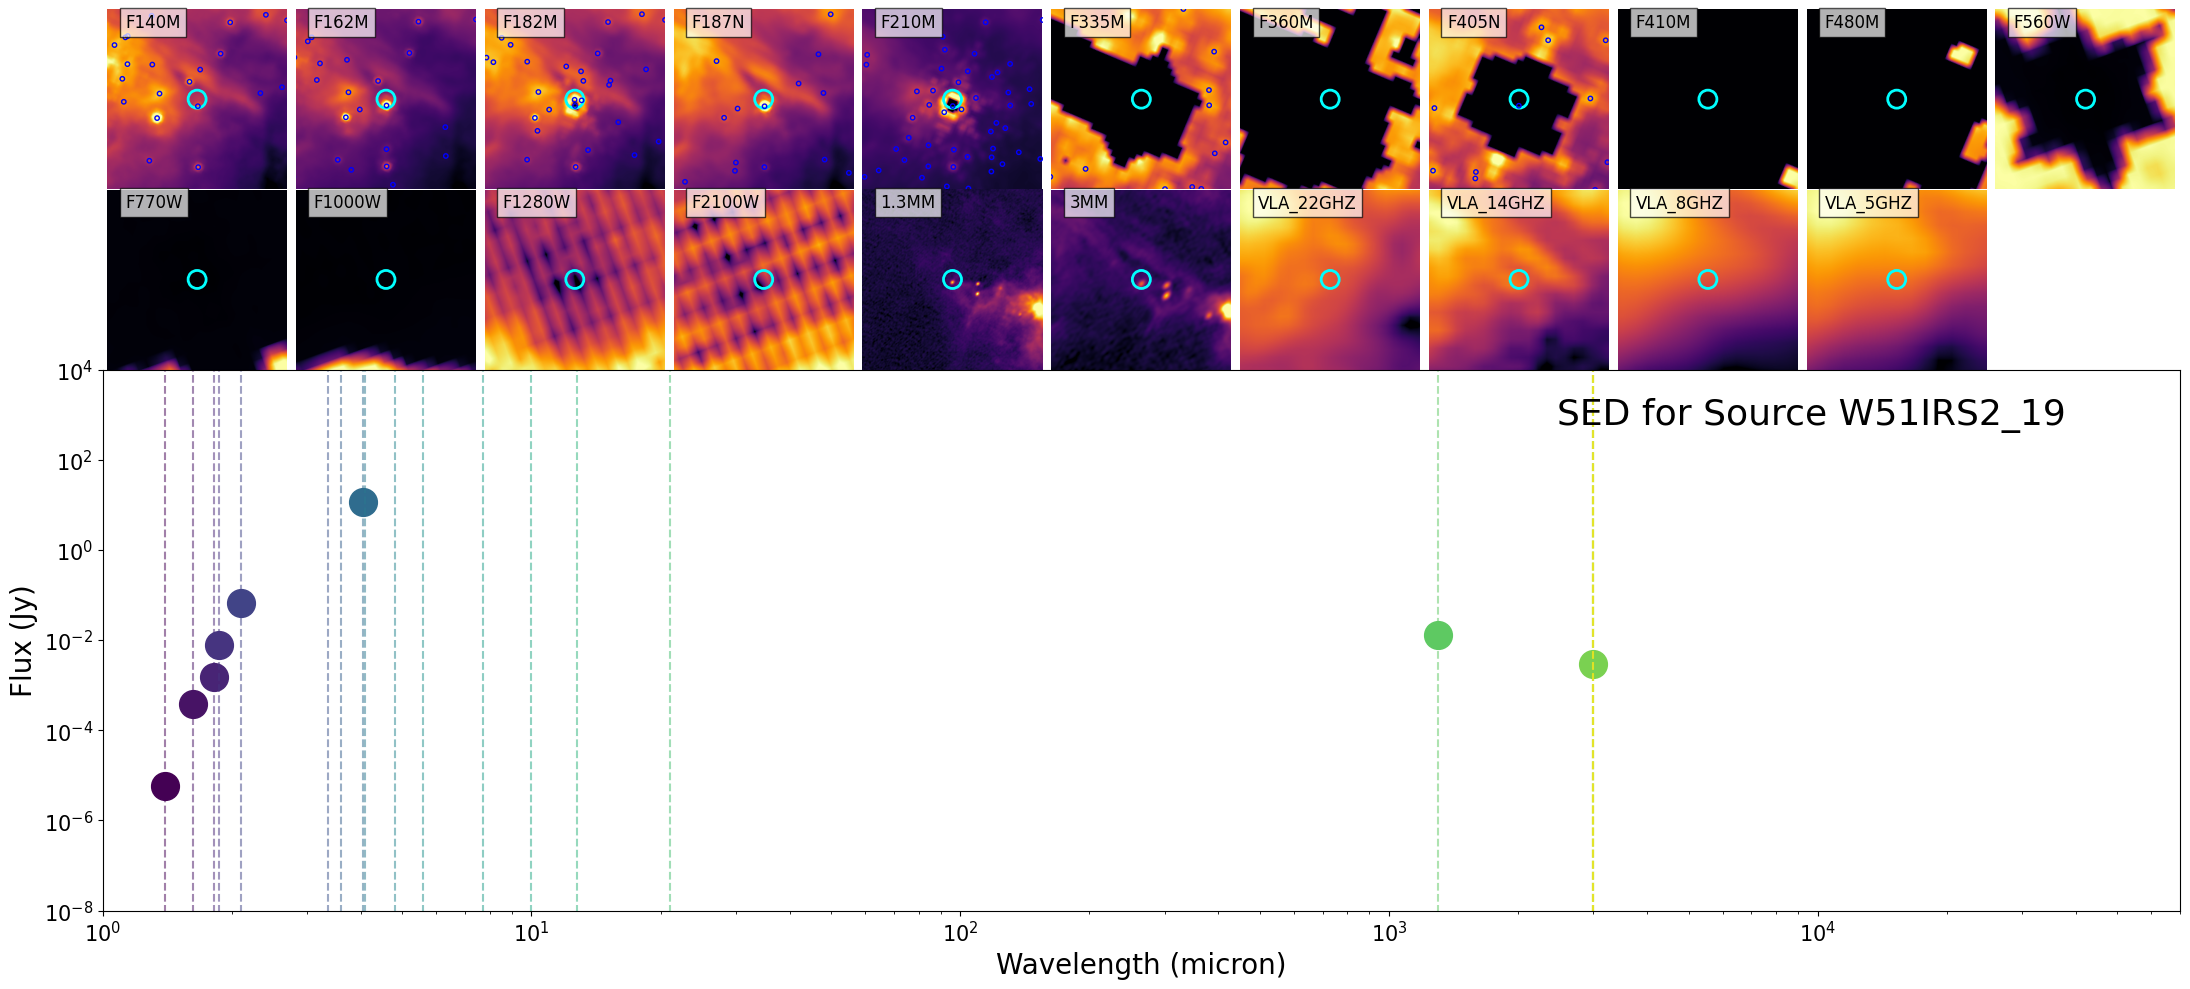

W51n ALMA source index: 22, matched JWST catalog index: 49642, separation: [0.05851041] arcsec
No VLA sources found within 0.1 arcsec of ALMA source 22
skycoords in h:m:s: 19h23m40.92909642s +14d31m07.62781985s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51n_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51n_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_sat

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f187n, Wavelength: 1.87 micron, Flux: 0.0 Jy
f210m
flux_jy: 0.0 Jy
Flux for filter f210m is NaN or non-positive, checking catalogs for upper limits...
7.52514718037244e-11 deg2
Filter: f210m, Wavelength: 2.1 micron, Flux: 0.0 Jy
f335m
flux_jy: 0.0 Jy
Flux for filter f335m is NaN or non-positive, checking catalogs for upper limits...
Filter: f335m, Wavelength: 3.35 micron, Flux: 0.0 Jy
f360m
flux_jy: 0.0 Jy
Flux for filter f360m is NaN or non-positive, checking catalogs for upper limits...
3.0536898714608487e-10 deg2
Filter: f360m, Wavelength: 3.6 micron, Flux: 0.0 Jy
f405n
flux_jy: 0.0 Jy
Flux for filter f405n is NaN or non-positive, checking catalogs for upper limits...
flux_nrca:      flux_fit    
-----------------
5615.610920649055
Filter: f405n, Wavelength: 4.05 micron, Flux: 0.000522859771755772 Jy
f410m
flux_jy: 0.0 Jy
Flux for filter f410m is NaN or non-positive, checking catalogs for upper limits...
flux_nrca:      flux_fit    
-----------------
5467.517651914444
Filter

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


flux_nrca:      flux_fit     
------------------
23834.387601115926
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.0022178020756674056 Jy
f560w
flux_jy: 0.0 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.004312030905277425 Jy
f770w
flux_jy: 0.0 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.012009442840989717 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.0023995757220743024 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.0023995757220743024 Jy
flux_jy: 0.0003878210109044078 Jy
Filter: 3mm, Wavelength: 3000 micron, Flux: 0.0003878210109044078 Jy
flux_jy: nan Jy
Filter: vla_22GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_14GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_8GHz, Wavelength: 3000 micron, Flux: nan

...

Filter: f405n, Wavelength: 4.05 micron, Flux: 0.0 Jy
f410m
flux_jy: 0.0 Jy
Flux for filter f410m is NaN or non-positive, checking catalogs for upper limits...
Filter: f410m, Wavelength: 4.1 micron, Flux: 0.0 Jy
f480m
flux_jy: 0.0 Jy
Flux for filter f480m is NaN or non-positive, checking catalogs for upper limits...
flux_nrca:      flux_fit    
-----------------
40940.63354323111
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.003809547095183825 Jy
f560w
flux_jy: 0.0 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.0 Jy
f770w
flux_jy: 0.0 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.0 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.0 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.0 Jy
flux_jy: 0.0008177036989926678 Jy
Filter: 3mm, Wavelength: 3000 micron, Fl

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f410m, Wavelength: 4.1 micron, Flux: 0.0 Jy
f480m
flux_jy: 0.0 Jy
Flux for filter f480m is NaN or non-positive, checking catalogs for upper limits...
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.0 Jy
f560w


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


flux_jy: 0.0 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.0 Jy
f770w
flux_jy: 0.0 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.0 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.0 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.0 Jy
flux_jy: 0.0004082867329573806 Jy
Filter: 3mm, Wavelength: 3000 micron, Flux: 0.0004082867329573806 Jy
flux_jy: nan Jy
Filter: vla_22GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_14GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_8GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_5GHz, Wavelength: 3000 micron, Flux: nan Jy
fluxarr [np.float64(0.0), np.float64(0.0), np.float64(2.5072367881825783e-06), np.float64(0.0), np.float64(3.0241287568862545e-06), np.float64(0.0), np.float64(0.0),

In [ ]:
vla_ra = vla_cat['GRAdeg']
vla_dec = vla_cat['GDEdeg']
finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
vla_cat_updated = vla_cat[finite_idx]

w51n_alma_tab = Table.read(w51n_alma_catalog)
print(w51n_alma_tab.colnames)
w51n_alma_ra = Table.read(w51n_alma_catalog)['ra']
w51n_alma_dec = Table.read(w51n_alma_catalog)['dec']
mag_f182m_w51n_arr = []
mag_f210m_w51n_arr = []
mag_f360m_w51n_arr = []
mag_f480m_w51n_arr = []
label_w51n_arr =[]
for ii,id in enumerate(w51n_matched_idx):
    if True:
        if ii==0: 
            show=True
        else:
            show =False
        skycoord_alma = SkyCoord(ra=w51n_alma_ra[id]*u.deg, dec=w51n_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51n ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51n_alma_catalog)[id]
        
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the name of sources in the VLA catalog that have the cloest match to the ALMA source and their separation in arcsec
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(row_vla)
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
            name_vla_matched = row_vla['Name']
            row_vla = vla_cat_updated[vla_cat_updated['Name'] == name_vla_matched[0]]
        else:
            row_vla = None
            print(f"No VLA sources found within 0.1 arcsec of ALMA source {id}")
         
        mag_f182m,mag_f210m,mag_f360m,mag_f480m,label = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51IRS2_{id}", show=show, alma_region='w51n')
        if mag_f182m is not None:
            mag_f182m_w51n_arr.append(mag_f182m)
            mag_f210m_w51n_arr.append(mag_f210m)
            mag_f360m_w51n_arr.append(mag_f360m)
            mag_f480m_w51n_arr.append(mag_f480m)
            label_w51n_arr.append(label)

['b3_id', 'b6_id', 'b3_xpix', 'b3_ypix', 'b6_xpix', 'b6_ypix', 'b3_xsky', 'b3_ysky', 'b6_xsky', 'b6_ysky', 'ra', 'dec', 'b3_afwhm', 'b3_bfwhm', 'b3_pa', 'b6_afwhm', 'b6_bfwhm', 'b6_pa', 'is_matched', 'is_overlap', 'flux_peak_b3', 'flux_peak_b6', 'alpha', 'alphaerr', 'group', 'temp', 'constT_mass', 'MBBT_mass', 'constT_mass_err', 'MBBT_mass_err', 'inincore_b3fov', 'flux_b3', 'flux_err_b3', 'pa_b3', 'pa_err_b3', 'fitted_major_b3', 'fitted_major_err_b3', 'fitted_minor_b3', 'fitted_minor_err_b3', 'deconvolved_major_b3', 'deconvolved_minor_b3', 'deconvolved_angle_b3', 'peak_flux_b3', 'least_chi_square_b3', 'flux_b6', 'flux_err_b6', 'pa_b6', 'pa_err_b6', 'fitted_major_b6', 'fitted_major_err_b6', 'fitted_minor_b6', 'fitted_minor_err_b6', 'deconvolved_major_b6', 'deconvolved_minor_b6', 'deconvolved_angle_b6', 'peak_flux_b6', 'least_chi_square_b6', 'flux_b6_conv', 'flux_err_b6_conv', 'pa_b6_conv', 'pa_err_b6_conv', 'fitted_major_b6_conv', 'fitted_major_err_b6_conv', 'fitted_minor_b6_conv', 'fit

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f187n, Wavelength: 1.87 micron, Flux: 0.0 Jy
f210m
flux_jy: 0.0 Jy
Flux for filter f210m is NaN or non-positive, checking catalogs for upper limits...
7.52514718037244e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f210m, Wavelength: 2.1 micron, Flux: 0.0 Jy
f335m
flux_jy: 0.0 Jy
Flux for filter f335m is NaN or non-positive, checking catalogs for upper limits...
Filter: f335m, Wavelength: 3.35 micron, Flux: 0.0 Jy
f360m
flux_jy: 0.0 Jy
Flux for filter f360m is NaN or non-positive, checking catalogs for upper limits...
3.0536898714608487e-10 deg2
Filter: f360m, Wavelength: 3.6 micron, Flux: 0.0 Jy
f405n
flux_jy: 0.0 Jy
Flux for filter f405n is NaN or non-positive, checking catalogs for upper limits...
Filter: f405n, Wavelength: 4.05 micron, Flux: 0.0 Jy
f410m
flux_jy: 0.0 Jy
Flux for filter f410m is NaN or non-positive, checking catalogs for upper limits...
Filter: f410m, Wavelength: 4.1 micron, Flux: 0.0 Jy
f480m
flux_jy: 4.77285611755123e-05 Jy
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 4.77285611755123e-05 Jy
f560w
flux_jy: 0.00015338158235765544 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.00015338158235765544 Jy
f770w
flux_jy: 0.0005095114012773543 Jy

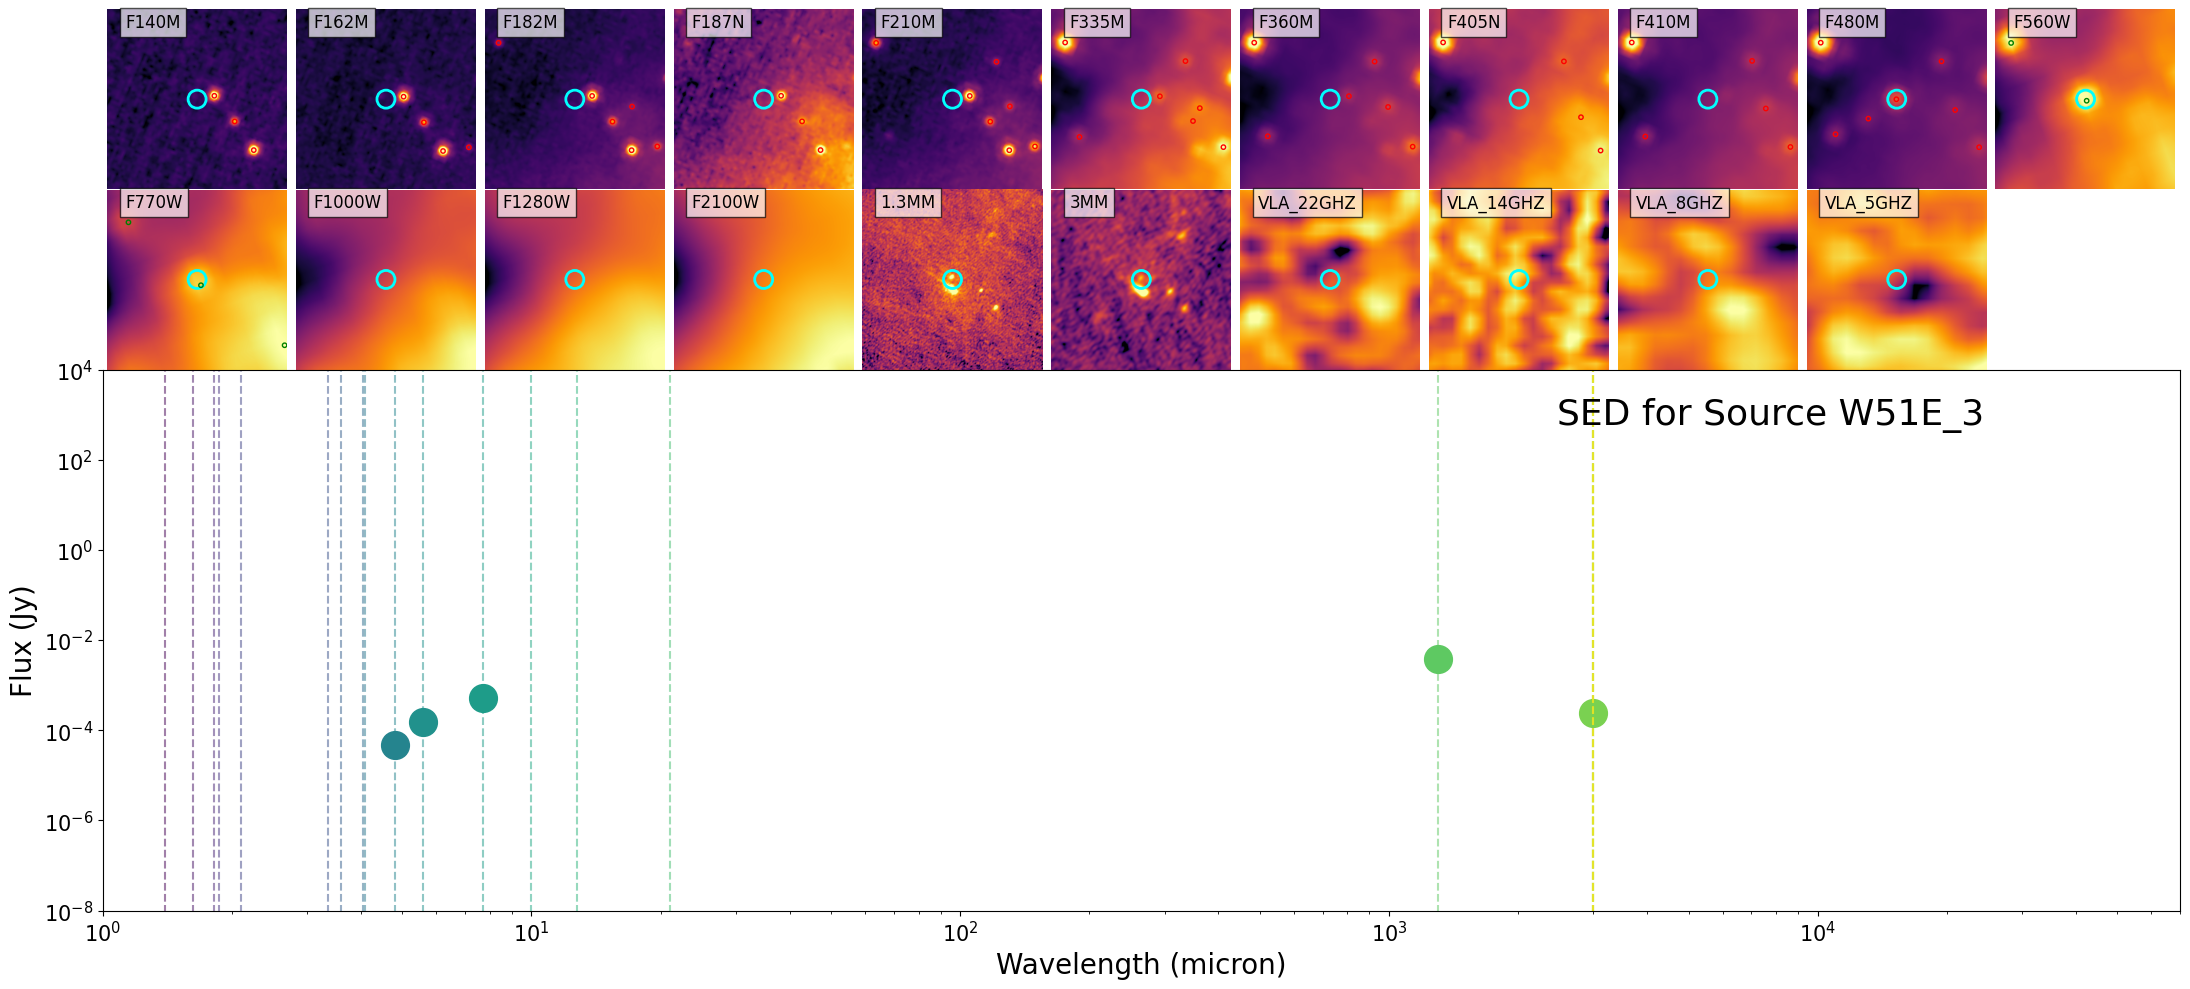

W51e ALMA source index: 7, matched JWST catalog index: 133964, separation: [0.03937118] arcsec
No VLA sources found within 0.1 arcsec of ALMA source 7
skycoords in h:m:s: 19h23m43.50583402s +14d30m21.79695539s
21 21
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f140m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f140m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
catalog filename cat_nrcb: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrcb_indivexp_merged_dao_after_merger_combined_with_satstars_nmatch_cut_grade_a.fits
JWST image filename: /orange/adamginsburg/jwst/w51/reproject_to_alma/f162m_reprojected_to_alma_w51e_b3.fits
pixel_scale: 1.944444444444e-06 deg
f162m
catalog filename cat_nrca: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_sats

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


flux_jy: 0.0 Jy
Flux for filter f210m is NaN or non-positive, checking catalogs for upper limits...
7.52514718037244e-11 deg2
Filter: f210m, Wavelength: 2.1 micron, Flux: 0.0 Jy
f335m
flux_jy: 0.0 Jy
Flux for filter f335m is NaN or non-positive, checking catalogs for upper limits...


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f335m, Wavelength: 3.35 micron, Flux: 0.0 Jy
f360m
flux_jy: 3.355233765077887e-05 Jy
3.0536898714608487e-10 deg2
Filter: f360m, Wavelength: 3.6 micron, Flux: 3.355233765077887e-05 Jy
f405n
flux_jy: 0.0003447071532895812 Jy
Filter: f405n, Wavelength: 4.05 micron, Flux: 0.0003447071532895812 Jy
f410m
flux_jy: 0.00029278762433063474 Jy
Filter: f410m, Wavelength: 4.1 micron, Flux: 0.00029278762433063474 Jy
f480m
flux_jy: 0.002296852903137679 Jy
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.002296852903137679 Jy
f560w
flux_jy: 0.004538950933719309 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.004538950933719309 Jy
f770w
flux_jy: 0.008198335338532493 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.008198335338532493 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux

...

Filter: f770w, Wavelength: 7.7 micron, Flux: 0.0 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.00919474889933895 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.00919474889933895 Jy
flux_jy: 0.0025296606242456547 Jy
Filter: 3mm, Wavelength: 3000 micron, Flux: 0.0025296606242456547 Jy
flux_jy: nan Jy
Filter: vla_22GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_14GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_8GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_5GHz, Wavelength: 3000 micron, Flux: nan Jy
fluxarr [np.float64(4.704720219697238e-07), np.float64(9.171803502751136e-07), np.float64(1.141485315400053e-06), np.float64(0.0), np.float64(1.3883008536907176e-06), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.fl

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Filter: f335m, Wavelength: 3.35 micron, Flux: 0.0 Jy
f360m
flux_jy: 6.340699785465595e-06 Jy
3.0536898714608487e-10 deg2
Filter: f360m, Wavelength: 3.6 micron, Flux: 6.340699785465595e-06 Jy
f405n
flux_jy: 0.0 Jy
Flux for filter f405n is NaN or non-positive, checking catalogs for upper limits...
Filter: f405n, Wavelength: 4.05 micron, Flux: 0.0 Jy
f410m
flux_jy: 5.095972996245743e-05 Jy
Filter: f410m, Wavelength: 4.1 micron, Flux: 5.095972996245743e-05 Jy
f480m
flux_jy: 0.0005056525204139437 Jy
3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.0005056525204139437 Jy
f560w
flux_jy: 0.0014616920926859174 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 0.0014616920926859174 Jy
f770w
flux_jy: 0.002802587506050392 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.002802587506050392 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: 

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


3.054668262896466e-10 deg2
Filter: f480m, Wavelength: 4.8 micron, Flux: 0.0 Jy
f560w
flux_jy: 2.596333834380558 Jy
Filter: f560w, Wavelength: 5.6 micron, Flux: 2.596333834380558 Jy
f770w
flux_jy: 0.0 Jy
Filter: f770w, Wavelength: 7.7 micron, Flux: 0.0 Jy
f1000w
flux_jy: 0.0 Jy
Filter: f1000w, Wavelength: 10.0 micron, Flux: 0.0 Jy
f1280w
flux_jy: 0.0 Jy
Filter: f1280w, Wavelength: 12.8 micron, Flux: 0.0 Jy
f2100w
flux_jy: 0.0 Jy
Filter: f2100w, Wavelength: 21.0 micron, Flux: 0.0 Jy
flux_jy: 0.0021393084640484567 Jy
Filter: 1.3mm, Wavelength: 1300 micron, Flux: 0.0021393084640484567 Jy
flux_jy: 0.0008134162631960608 Jy
Filter: 3mm, Wavelength: 3000 micron, Flux: 0.0008134162631960608 Jy
flux_jy: nan Jy
Filter: vla_22GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_14GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_8GHz, Wavelength: 3000 micron, Flux: nan Jy
flux_jy: nan Jy
Filter: vla_5GHz, Wavelength: 3000 micron, Flux: nan Jy
fluxarr [np.floa

In [ ]:
vla_ra = vla_cat['GRAdeg']
vla_dec = vla_cat['GDEdeg']
finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
vla_cat_updated = vla_cat[finite_idx]

w51e_alma_tab = Table.read(w51e_alma_catalog)
print(w51e_alma_tab.colnames)
w51e_alma_ra = Table.read(w51e_alma_catalog)['ra']
w51e_alma_dec = Table.read(w51e_alma_catalog)['dec']
mag_f182m_w51e_arr = []
mag_f210m_w51e_arr = []
mag_f360m_w51e_arr = []
mag_f480m_w51e_arr = []
label_w51e_arr = []
for ii,id in enumerate(w51e_matched_idx):
    if True:
        if ii==0: 
            show=True
        else:
            show =False
        skycoord_alma = SkyCoord(ra=w51e_alma_ra[id]*u.deg, dec=w51e_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51e ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51e_alma_catalog)[id]
        
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the name of sources in the VLA catalog that have the cloest match to the ALMA source and their separation in arcsec
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(row_vla)
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
            name_vla_matched = row_vla['Name']
            row_vla = vla_cat_updated[vla_cat_updated['Name'] == name_vla_matched[0]]
        else:
            row_vla = None
            print(f"No VLA sources found within 0.1 arcsec of ALMA source {id}")
         
        mag_f182m,mag_f210m,mag_f360m,mag_f480m,label = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51E_{id}", show=show, alma_region='w51e')
        if mag_f182m is not None:
            mag_f182m_w51e_arr.append(mag_f182m)
            mag_f210m_w51e_arr.append(mag_f210m)
            mag_f360m_w51e_arr.append(mag_f360m)
            mag_f480m_w51e_arr.append(mag_f480m)
            label_w51e_arr.append(label)

In [ ]:
"""
vla_ra = vla_cat['GRAdeg']
vla_dec = vla_cat['GDEdeg']
finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
vla_cat_updated = vla_cat[finite_idx]

w51n_alma_tab = Table.read(w51n_alma_catalog)
print(w51n_alma_tab.colnames)
w51n_alma_ra = Table.read(w51n_alma_catalog)['ra']
w51n_alma_dec = Table.read(w51n_alma_catalog)['dec']
mag_f140m_w51n_arr = []
mag_f210m_w51n_arr = []
mag_f360m_w51n_arr = []
mag_f480m_w51n_arr = []
for ii,id in enumerate(w51n_matched_idx):
    if ii==3:
        if ii==3: 
            show=True
        else:
            show =False
        skycoord_alma = SkyCoord(ra=w51n_alma_ra[id]*u.deg, dec=w51n_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51n ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51n_alma_catalog)[id]
        
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the name of sources in the VLA catalog that have the cloest match to the ALMA source and their separation in arcsec
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(row_vla)
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
            name_vla_matched = row_vla['Name']
            row_vla = vla_cat_updated[vla_cat_updated['Name'] == name_vla_matched[0]]
        else:
            row_vla = None
            print(f"No VLA sources found within 0.1 arcsec of ALMA source {id}")
         
        mags = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51IRS2_{id}", show=show, alma_region='w51n')
        if mags is not None:
            mag_f140m_w51n_arr.append(mags[0].value)
            mag_f210m_w51n_arr.append(mags[1].value)
            mag_f360m_w51n_arr.append(mags[2].value)
            mag_f480m_w51n_arr.append(mags[3].value)
"""

'\nvla_ra = vla_cat[\'GRAdeg\']\nvla_dec = vla_cat[\'GDEdeg\']\nfinite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)\nvla_cat_updated = vla_cat[finite_idx]\n\nw51n_alma_tab = Table.read(w51n_alma_catalog)\nprint(w51n_alma_tab.colnames)\nw51n_alma_ra = Table.read(w51n_alma_catalog)[\'ra\']\nw51n_alma_dec = Table.read(w51n_alma_catalog)[\'dec\']\nmag_f140m_w51n_arr = []\nmag_f210m_w51n_arr = []\nmag_f360m_w51n_arr = []\nmag_f480m_w51n_arr = []\nfor ii,id in enumerate(w51n_matched_idx):\n    if ii==3:\n        if ii==3: \n            show=True\n        else:\n            show =False\n        skycoord_alma = SkyCoord(ra=w51n_alma_ra[id]*u.deg, dec=w51n_alma_dec[id]*u.deg)\n        skycoord_jwst = SkyCoord(ra=jwst_tab[\'skycoord_ref\'].ra, dec=jwst_tab[\'skycoord_ref\'].dec)\n        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)\n        print(f"W51n ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")\n        row_jwst = jwst_

In [ ]:
"""
mag_f140m_w51e_arr = []
mag_f210m_w51e_arr = []
mag_f360m_w51e_arr = []
mag_f480m_w51e_arr = []
for ii,id in enumerate(w51e_matched_idx):
    if ii==len(w51e_matched_idx)-1:
        show=True
   
        skycoord_alma = SkyCoord(ra=w51e_alma_ra[id]*u.deg, dec=w51e_alma_dec[id]*u.deg)
        skycoord_jwst = SkyCoord(ra=jwst_tab['skycoord_ref'].ra, dec=jwst_tab['skycoord_ref'].dec)
        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
        print(f"W51e ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
        row_jwst = jwst_tab[idx]
        row_alma = Table.read(w51e_alma_catalog)[id]
        vla_ra = vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
        vla_cat_updated = vla_cat_updated[finite_idx]
        vla_ra= vla_cat_updated['GRAdeg']
        vla_dec = vla_cat_updated['GDEdeg']
        
        skycoord_vla = SkyCoord(ra=vla_ra, dec=vla_dec)
        # get the indices of the VLA sources that are within 0.1 arcsec from the ALMA source
        separations = skycoord_vla.separation(skycoord_alma)
        vla_match_idx = np.where(separations < 0.1*u.arcsec)[0]
        if len(vla_match_idx) > 0:
            row_vla = vla_cat_updated[vla_match_idx]
            print(f"Found {len(row_vla)} VLA sources within 0.1 arcsec of ALMA source {id}")
        else:
            row_vla = None
        print('row_vla', row_vla)   
        mags = plot_SED(image_filenames, row_jwst, row_alma, row_vla, f"W51E_{id}", show=show)
        if mags is not None:
            mag_f140m_w51e_arr.append(mags[0].value)
            mag_f210m_w51e_arr.append(mags[1].value)
            mag_f360m_w51e_arr.append(mags[2].value)
            mag_f480m_w51e_arr.append(mags[3].value)
"""

'\nmag_f140m_w51e_arr = []\nmag_f210m_w51e_arr = []\nmag_f360m_w51e_arr = []\nmag_f480m_w51e_arr = []\nfor ii,id in enumerate(w51e_matched_idx):\n    if ii==len(w51e_matched_idx)-1:\n        show=True\n\n        skycoord_alma = SkyCoord(ra=w51e_alma_ra[id]*u.deg, dec=w51e_alma_dec[id]*u.deg)\n        skycoord_jwst = SkyCoord(ra=jwst_tab[\'skycoord_ref\'].ra, dec=jwst_tab[\'skycoord_ref\'].dec)\n        idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)\n        print(f"W51e ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")\n        row_jwst = jwst_tab[idx]\n        row_alma = Table.read(w51e_alma_catalog)[id]\n        vla_ra = vla_cat_updated[\'GRAdeg\']\n        vla_dec = vla_cat_updated[\'GDEdeg\']\n        finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)\n        vla_cat_updated = vla_cat_updated[finite_idx]\n        vla_ra= vla_cat_updated[\'GRAdeg\']\n        vla_dec = vla_cat_updated[\'GDEdeg\']\n\n        skycoord

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3

9.49145905084584e-10 deg2
9.491458943030916e-10 deg2
9.49145885655769e-10 deg2
9.491458757317268e-10 deg2
7.524574264515582e-11 deg2
color
[0.29376055        nan 0.27510624 ...        nan        nan        nan] mag
ho
[21.5261589  12.56874713 20.22625224 22.25657218 20.09176143 18.37312084] [18.28273234 11.57632997 18.40431969 18.76621003 18.39027981 16.57742549] [11.24514908  9.19784709 13.6185351  11.07766655 14.51233893 11.74408995] [ 8.90756141  8.82766063 11.99097654  8.46432444 12.87543484 10.35808917]


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


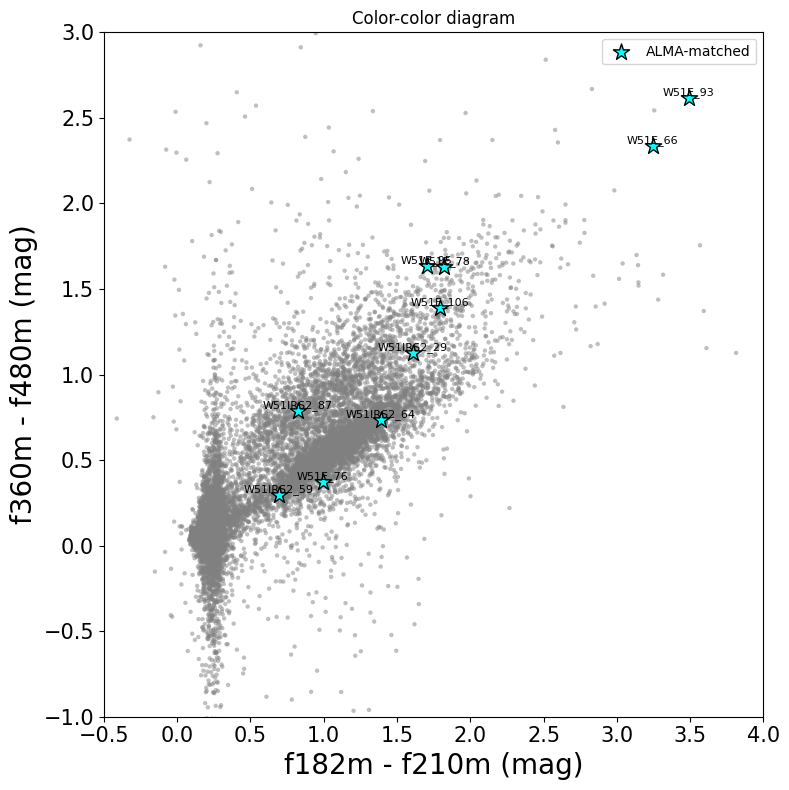

In [ ]:
def get_mag_from_catalog(flux, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    #flux= (flux * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
   # eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
 #   abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
#    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
 #   vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag
f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))

f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))
flux_f140m_jy = (catalog['flux_fit_f140m'] * u.MJy/u.sr * WCS(f140m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f162m_jy = (catalog['flux_fit_f162m'] * u.MJy/u.sr * WCS(f162m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f182m_jy = (catalog['flux_fit_f182m'] * u.MJy/u.sr * WCS(f182m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f187n_jy = (catalog['flux_fit_f187n'] * u.MJy/u.sr * WCS(f187n_header).proj_plane_pixel_area()).to(u.Jy)
flux_f210m_jy = (catalog['flux_fit_f210m'] * u.MJy/u.sr * WCS(f210m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f335m_jy = (catalog['flux_fit_f335m'] * u.MJy/u.sr * WCS(f335m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f360m_jy = (catalog['flux_fit_f360m'] * u.MJy/u.sr * WCS(f360m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f405n_jy = (catalog['flux_fit_f405n'] * u.MJy/u.sr * WCS(f405n_header).proj_plane_pixel_area()).to(u.Jy)
flux_f410m_jy = (catalog['flux_fit_f410m'] * u.MJy/u.sr * WCS(f410m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f480m_jy = (catalog['flux_fit_f480m'] * u.MJy/u.sr * WCS(f480m_header).proj_plane_pixel_area()).to(u.Jy)
flux_f560w_jy = (catalog['flux_fit_f560w'] * u.MJy/u.sr * WCS(f560w_header).proj_plane_pixel_area()).to(u.Jy)
flux_f770w_jy = (catalog['flux_fit_f770w'] * u.MJy/u.sr * WCS(f770w_header).proj_plane_pixel_area()).to(u.Jy)
flux_f1000w_jy = (catalog['flux_fit_f1000w'] * u.MJy/u.sr * WCS(f1000w_header).proj_plane_pixel_area()).to(u.Jy)
flux_f1280w_jy = (catalog['flux_fit_f1280w'] * u.MJy/u.sr * WCS(f1280w_header).proj_plane_pixel_area()).to(u.Jy)
flux_f2100w_jy = (catalog['flux_fit_f2100w'] * u.MJy/u.sr * WCS(f2100w_header).proj_plane_pixel_area()).to(u.Jy)
f140m_mag = get_mag(flux_f140m_jy, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(flux_f162m_jy, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(flux_f182m_jy, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(flux_f210m_jy, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(flux_f335m_jy, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(flux_f360m_jy, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(flux_f405n_jy, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(flux_f410m_jy, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(flux_f480m_jy, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(flux_f560w_jy, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(flux_f770w_jy, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(flux_f1000w_jy, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag_from_catalog(flux_f1280w_jy, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag_from_catalog(flux_f2100w_jy, WCS(f2100w_header), filtername='f2100w')

f187n_mag = get_mag(flux_f187n_jy, WCS(f187n_header), filtername='f187n')
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, CT06_MWGC, G21_MWAvg, RRP89_MWGC, G24_SMCAvg
def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)

# 140-210 vs 360-480 color coded by paa excess
print('color')
print(color1)
color1 = filters['f182m'] - filters['f210m']
color2 = filters['f360m'] - filters['f480m']
fig = plt.figure(figsize=(8,8))
ax = fig.add_axes(111)
cmap = plt.get_cmap('rainbow')
#norm = plt.Normalize(vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.scatter(color1.value, color2.value, s=10, color='gray', alpha=0.5, edgecolor='none')
ax.set_xlabel('f182m - f210m (mag)')
ax.set_ylabel('f360m - f480m (mag)')
ax.set_title('Color-color diagram')
#cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
#cbar.set_label('Paα line excess (Jy)')
ax.set_ylim(-1,3)

colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
"""
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), CT06_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'CT06 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f140m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=30, color=c,
                     color1_data=color1, color2_data=color2, start=(2,0.5), label=labels)
"""
print('ho')
magarr_f182m_w51e = np.array([mag.value for mag in mag_f182m_w51e_arr])
magarr_f210m_w51e = np.array([mag.value for mag in mag_f210m_w51e_arr])
magarr_f360m_w51e = np.array([mag.value for mag in mag_f360m_w51e_arr])
magarr_f480m_w51e = np.array([mag.value for mag in mag_f480m_w51e_arr])
magarr_f182m_w51n = np.array([mag.value for mag in mag_f182m_w51n_arr])
magarr_f210m_w51n = np.array([mag.value for mag in mag_f210m_w51n_arr])
magarr_f360m_w51n = np.array([mag.value for mag in mag_f360m_w51n_arr])
magarr_f480m_w51n = np.array([mag.value for mag in mag_f480m_w51n_arr])
print(magarr_f182m_w51e, magarr_f210m_w51e, magarr_f360m_w51e, magarr_f480m_w51e)
ax.scatter(magarr_f182m_w51e - magarr_f210m_w51e, magarr_f360m_w51e - magarr_f480m_w51e, edgecolor='k', s=150, c='cyan', marker='*', label='ALMA-matched')
ax.scatter(magarr_f182m_w51n - magarr_f210m_w51n, magarr_f360m_w51n - magarr_f480m_w51n, edgecolor='k', s=150, c='cyan', marker='*', )
for x,y,label in zip(magarr_f182m_w51e - magarr_f210m_w51e, magarr_f360m_w51e - magarr_f480m_w51e, label_w51e_arr):
    ax.text(x, y, label, fontsize=8, ha='center', va='bottom')
for x,y,label in zip(magarr_f182m_w51n - magarr_f210m_w51n, magarr_f360m_w51n - magarr_f480m_w51n, label_w51n_arr):
    ax.text(x, y, label, fontsize=8, ha='center', va='bottom')


ax.set_xlim(-0.5,4)
ax.set_ylim(-1,3)
ax.legend()
plt.tight_layout()
plt.show()
